# Inicio
Conexión con google drive.

In [ ]:
#from google.colab import drive
#drive.mount('/content/gdrive')

La celda devuelve lo siguiente:

<figure>
<center>
<img src='https://drive.google.com/thumbnail?id=1FjfwBMl6uE4ouU4WBEJ-2mqBw6eIfa7P'/>
</figure>

Haga clic en el enlace, dé acceso a Google Colab a su unidad y copie el código de autorización. Pégelo y listo. Ahora puede acceder a sus archivos de Google Drive en.

/content/drive/My Drive/

Use el panel de la izquierda para navegar en la unidad.

# Práctica 1. Introducción a las señales aleatorias
En esta práctica repasaremos algunos de los conceptos fundamentales asociados al procesado de señales aleatorias. En concreto, practicaremos con la estimación de funciones de densidad de probabilidad y de algunos de los estadísticos más importantes, como la media, la varianza, la correlación y la covarianza.

Para poder utilizar los paquetes de código (librerías) de python, debemos primero importarlos al espacio de trabajo, para lo que utilizaresmo el comando *import*. Recuerde que siempre, **SIEMPRE**, debe comentar el código. Dado que el objetivo de este documento es el de realizar prácticas que serán evaluadas, comente **TODO EL CÓDIGO**. Para escribir un comentario utilice la almhadilla (*#*).

In [ ]:
# En este bloque importaremos las librerías que vamos a utilizar
import numpy as np  # importamos numpy, librería de cálculo científico
from scipy import signal  # importamos numpy, librería de procesado de señal
from scipy import stats  # importamos numpy, librería de estadística y probabilidad
import matplotlib.pylab as plt  # importamos matplotly, librería para representacion gráfica

## 0.- Variables aleatorias
Una Variable Aleatoria (VA) es una función que asigna un valor numérico a los resultados de un experimento. En nuestro caso, las VA serán generalmente señales aleatorias. Vamos a comenzar trabajando con señales aleatorias sintéticas, esto es, señales artificiales creadas por nosostros mismos para realizar pruebas. Para ello utilizaremos la librería [numpy.random](https://numpy.org/doc/stable/reference/random/index.html). Vamos a probar primero con las más básicas, una distribución Uniforme y una Normal (o Gaussiana), y lo haremos con las funciones básicas existentes en la librería numpy: *rand* y *randn*, para la uniforme y la normal respectivamente.

Muestras de la distribución uniforme U[0,1]:
[0.77864225 0.03957608 0.10005536 ... 0.15218336 0.04710369 0.57313292]
Muestras de la distribución normal N[0,1]:
[ 0.7862014  -0.77323345  0.97760861 ...  0.47137288 -1.03983559
  1.45652122]


Text(0, 0.5, 'Normal')

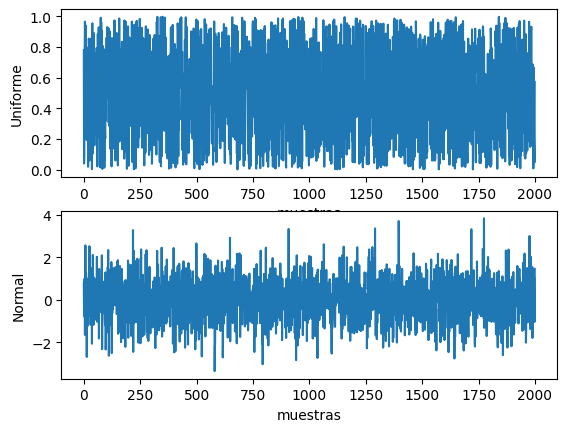

In [ ]:
from numpy import random  # importamos de forma específica la librería random

x_U = random.rand(2000) # crea un vector con 20 muestras generadas comom una U[0,1]
x_N = random.randn(2000) # crea un vector con 20 muestras generadas comom una N[0,1]

# mostramos los valores
print('Muestras de la distribución uniforme U[0,1]:')
print(x_U)
print('Muestras de la distribución normal N[0,1]:')
print(x_N)

# representación gráfica
# representa uniforme
fig = plt.figure(num='ejemplo distribuciones')
sp1 = fig.add_subplot(211)
sp1.plot(x_U)
sp1.set_xlabel('muestras')
sp1.set_ylabel('Uniforme')

#r representa normal
sp2 = fig.add_subplot(212)
sp2.plot(x_N)
sp2.set_xlabel('muestras')
sp2.set_ylabel('Normal')

## 1.- Histogramas y función de densidad de probabilidad.
La función de densidad de probabilidad (*fdp*) de una variable aleatoria $X$, es una función $f_X(x)$ que describe la probabilidad de que dicha variable tome un valor determinado. En el caso más habitual, la variable aleatoria es continua, y no es posible calcular la probabilidad de un valor aislado, pero sí se pude calcular la probabilidad de que la variable tome un valor dentro de un intervalo determinado.

Es decir, supongamos que tenemos una variable aletoria $X$ cuya *fdp* es $f_X(x)$, la probabilidad de que la variable tome un valor entre $\alpha_1$ y $\alpha_2$ se calcularía como:

$\begin{equation}
P\left ( \alpha_{1}\leq X\leq \alpha_{2} \right ) = \int_{\alpha_{2}}^{\alpha_{1}} f_X(x)\partial x
\end{equation}$

Por lo tanto, si queremos realizar cualquier cálculo o asunción relativa a una variable aleatoria (o lo que es lo mismo, un experimento o fenómeno aleatorio), sería necesario conocer su función de densidad de probabilidad. Al iniciar el estudio de cualquier fenómeno aleatorio, la primera tarea será la de estimar su función de densidad de probabilidad.

La forma más sencilla de realizar una primera estimación de la función de densidad de probabilidad es  la frecuencia relativa de los valores de la variable aleatoria. Es decir, dados unos valores de la variable aleatoria (unas realizaciones del experimento), dividimos el rango de posibles valores en intervalos de igual tamaño ($\Delta x_i$), y contamos cuantas veces la variable ha tomado un valor dentro de ese intervalo, $N_{\Delta x_i}$. La representación gráfica de esta cuenta en forma de gráfica de barras se llama *histograma*, y es de uso muy habitual en tratamiento estadístico de señales. Si dividimos ahora los valores obtenidos por el total de muestras de la variable ($N$), tenemos la frecuencia relativa, que sería la probabilidad empírica de que la variable tome un valor en un intervalo determinado.

$\begin{equation}
f_r=\frac{N_{\Delta x_i}}{N}
\end{equation}$

Si tuvieramos muchas muestras ($N \rightarrow \infty$) y puedieramos hacer los intervalos muy pequeños ($\Delta x_i \rightarrow 0 \sim \partial x$), tendríamos una aproximación de la función de densidad de probabilidad.

En esta parte de la práctica vamos a estimar el función de densidad de probabilidad de una VA (bien sea las creadas por nosotros o las cargadas del disco), partiendo del histograma. Puesto que en un principio las VA son incontables, al ser valores de rango continuo entre los número reales, tendremos que dividir el histograma en intervalos equiespaciados. Utilizaremos la funcion [histogram](https://numpy.org/doc/stable/reference/generated/numpy.histogram.html) de numpy.

numpy.histogram(a, bins=10, range=None, normed=None, weights=None, density=None)

Antes de usarla, lea la documentación y describa el significado de los siguientes parámetros de entrada, escribiéndolo a continuación en la siguiente celda:

# Cuestion 1
a:

bins:

range:

density:


Implemente a continuación un código que calcule y represente el histograma de una señal aleatoria cualquiera en función de los parámetros *bins*, *range* y *density*. Indique claramente qué representa cada eje. Tenga en cuenta que algún parámetro de entrada puede modificar el significado de algún eje.


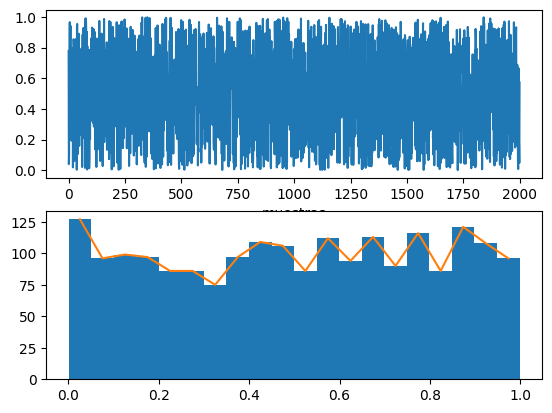

In [ ]:
MyData = x_U  # para especificar cuál usamos

myHist, myBinEdges = np.histogram(MyData, bins=20)

fig = plt.figure(num='ejemplo distribuciones')
sp1 = fig.add_subplot(211)
sp1.plot(MyData)
sp1.set_xlabel('muestras')

sp2 = fig.add_subplot(212)
# opción 1
#plt.bar(myBinEdges[0:-1], myHist, width=myBinEdges[1]-myBinEdges[0], align='edge')

# opción 2
sp2.hist(MyData, bins=myBinEdges);

sp2.plot(myBinEdges[0:-1] + (myBinEdges[1]-myBinEdges[0])/2, myHist)


Vamos ahora a añadir algo de funcionalidad al código, para poder explorar todas las opciones. Para ello utilizarsmos los formularios de colab: [forms](https://colab.research.google.com/notebooks/forms.ipynb). Use un formulario para decidir el tipo de distribución, el número de puntos, y los parámetros del histograma.

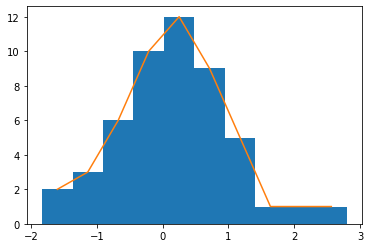

In [ ]:
#@title Análisis básico de señales aleatorias con histogramas

Distribucion = 'Normal' #@param ["Uniforme", "Normal"]
Numero_Muestras = 50 #@param {type:"integer"}
bins = 10 #@param {type:"integer"}
if Distribucion=='Uniforme':
  x = random.rand(Numero_Muestras)
elif Distribucion=='Normal':
  x = random.randn(Numero_Muestras)


myHist, myBinEdges = np.histogram(x, bins=bins)
plt.hist(x, bins=myBinEdges)
plt.plot(myBinEdges[0:-1] + (myBinEdges[1]-myBinEdges[0])/2, myHist)

Utilizando el código anterior, modifique los diferentes parámetros y observe y comente los resultados, contestando, al menos, a las siguientes preguntas, aunque puede añadir los comentarios que considere. Debe razonar todos sus comentarios.

---

# Cuestión 2
Si el número de muestras de la señal es bajo, ¿qué sucede? ¿es representativo de la distribución? ¿por qué? Ponga ejemplos con diferentes señales aumentando el número de muestras para comprobar el efecto.

# Cuestión 3
¿Cómo influye en el análisis el número de intervalos del histograma? Compruébelo con 10, 20, 50, 100 y 200 intervalos y comente los resultados. Tenga en cuenta que también dependerá del número de muestras de la señal.

# Cuestión 4
¿Cuál es la diferencia entre usar density=False o True?

# Cuestión 5
Escriba acontinuación una función que se llame myfdp(X, Nbins), que proporcione una estima de la fdp en función del número de intervalos Nbins. Compruebe que funciona y que cumple con las condiciones para ser una función de densidad de probabilidad.

# Cuestión 6
Escriba a continuación una función que, dada una fdp y unos intervalos obtenidos mediante la función anterior, permita estimar la probabilidad de que la señal tome un valor dentro de un rango $[\alpha_1, \alpha_2]$. Compruebe su funcionamiento con ejemplos.

# Cuestión 7
Pruebe las funciones anteriores con las señales proporcionadas en el archivo ejemplos_VA.rar. Estime, para cada una de ellas, qué tipo de distribución es. Justifique sus respuestas y comente los resultados.

## 2.- Media y Varianza.
La esperanza ($E\{X\}$ o $\mu_X$) de una VA se define como el valor esperado de la misma, que es un concepto similar a la media aritmética, si bien esto sólo es estrictamente cierto si se trata de VA ergódigcas. Es uno de los parámetros de una VA más importantes junto a la varianza ($VAR\{X\}$ o $\sigma_X^2$), que es una medida de la dispersión o variabilidad de la VA.

# Cuestión 8
Escriba en esta celda de texto, utilizando latex, la expresiones de los 2 parámetros.

# Cuestión 9
A continuación, escriba una función que permita calcular la media y la varianza en función de la estimación de la fdp realizada en apartados anteriores. Compruebe, utilizando las señales de ejemplo, que los valores coinciden con los obtyenidos utilizando las funciones mean y var de numpy.

## 3.- VA multidimensionales. Correlación y covarianza

### 3.1 Función de Correlación y correlación cruzada

# Cuestión 10
Describa qué es la función de correlación y para qué sirve. Escriba la fórmula de su cálculo asumiendo que las señales son estacionarias. Escriba un código en las siguientes celdas que permitan calcular y representar la autocorrelación y la correlación cruzada entre señales.

Tome las señales 1, 3, 7, 8 y 9 del archivo ejemplos_VA y calcule su autocorrelación. Comente los resultados. ¿Qué representa el valor de la autocorrelación en cero? ¿Cómo debería ser la autocorrelación teórica y por qué difiere de la calculada? ¿Cómo podría mejorarse la estima de la autocorrelación? Para estas preguntas asuma que las señales siguen las distribuciones calculadas en apartados anteriores.



### 3.2 Coeficiente de correlación y covarianza
# Cuestión 11
Describa qué son el coeficiende de correlación y covarianza, indicando las expresiones algebráicas para su cálculo. Indique para qué sirven estas medidas
Implemente un código que permita calcularlo para diferentes señales, y calcule las matrices de correlación y covarianza entre alguna de las señales del apartado anterior.
¿Qué puede deducir de los resultados? ¿Tiene algún sentido para ti?